## Linear regression model

Apply a linear regression model to predict the variable 'rate_avg'. Since the data can not be used as time series, we chose to consider the points as completely independent of time. Another choice could be to consider time series based on yearly division. 

Take aways from the EDA:

features that may have an importance: bedrooms, guest capacity, number of beds

features with minor importance: monthly price distribution, pool, gym, free parking, non-resident visitors, number of major events, temperature, rainfall

features to remove since data leakage:
ttm_avg_rate, l90d_avg_rate, maybe ttm_avg_rate_native?, l90d_avg_rate_native? 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
the_df=pd.read_csv('MSE446_cleaned_dataset.csv')
the_df.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,photos_count,superhost,latitude,...,listing_type_Private room in home,listing_type_Private room in loft,listing_type_Private room in rental unit,listing_type_Private room in townhouse,room_type_private_room,cancellation_policy_Flexible,cancellation_policy_Limited,cancellation_policy_Moderate,cancellation_policy_Strict,cancellation_policy_Super Strict 30 Days
0,4925824,2025-02-01,28,0,0.0,0,36.3,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
1,4925824,2025-03-01,31,0,0.0,0,35.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
2,4925824,2025-04-01,30,0,0.0,0,35.9,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
3,4925824,2025-05-01,31,0,0.0,0,36.0,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0
4,4925824,2025-06-01,30,0,0.0,0,36.5,7,1,43.6483,...,0,0,0,1,1,0,0,1,0,0


WARNING: sklearn doesn't work with dates. Possible to replace date '2025-10-01' by 3 columns year/month/day. This approach could be used if decide to work with time series, but TEMPORARILY, decide to DROP the 'date' column.

In [3]:
the_df=the_df.drop(columns=['listing_id','date'])

## Idea:
Apply the following process with different types of feature selection:
1. split data
2. develop and fit the model
3. predict using the model
4. evaluate the model
Types of feature selection to which the process above will be applied:
- simple selection based on highly correlated features
- lasso regression
- ridge regression

AUC, ROC, CV, bootstrap

K-fold CV: K=5-10 good

## Ridge regression

In [4]:
#delete same-named variables:
del X, y, X_train, X_test, y_train, y_test, predictions

NameError: name 'X' is not defined

Data split

In [11]:
from sklearn.model_selection import train_test_split

X = the_df.drop(columns=['rate_avg']) #select all columns except 'rate_avg'
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)
print('\n'+str(X_train.shape))
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3236, 121)

(2588, 121)
(648, 121)
(2588,)
(648,)


Fit model and hyperparameter tuning:

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#scale features, initiate model, use GridSearchCV, search for the best penality alpha between 0.1 and 5
pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
params = {'ridge__alpha': np.linspace(0.1, 5, 100)}
grid_ridge = GridSearchCV(pipe, params, scoring='neg_mean_absolute_error', cv=5)
#Possible regression metrics to use:
#neg_mean_squared_error (MSE)
#neg_mean_absolute_error (MAE)
#r2 (R-squared)
grid_ridge.fit(X_train, y_train) #fit the function to train set 

# Find the best parameter and see how well it performs on test set
print(grid_ridge.best_params_)
best_scaler = grid_ridge.best_estimator_.named_steps['scaler']
best_alpha=float(grid_ridge.best_params_['ridge__alpha'])
print(grid_ridge.score(X_test, y_test))
#print(grid_ridge.cv_results_['mean_test_score'])

X_train_scaled = best_scaler.transform(X_train)
X_test_scaled  = best_scaler.transform(X_test)

{'ridge__alpha': 3.762626262626263}
-13.690642140325451


results of the fit with the best alpha (penality coeff)

MAE:  13.690642140325451
MSE:  640.0641355701214
MAPE:  0.11314614264429977
R^2:  0.943142512600582


Text(0.5, 1.0, 'Using Ridge regression')

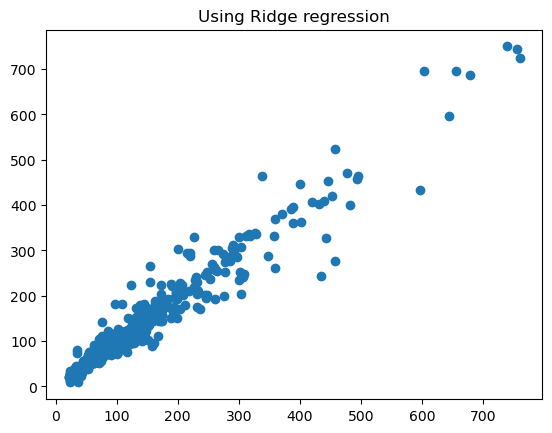

In [12]:
predict = grid_ridge.best_estimator_.predict(X_test)

from sklearn import metrics

print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', metrics.r2_score(y_test, predict))
plt.scatter(y_test, predict)
plt.title('Using Ridge regression')

#### Bootstrap
Bootstrap THE TRAINING SET to find confidence intervals and display the results

In [9]:
from sklearn.utils import resample
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score

score_mse = []
score_mae = []
score_mape = []
score_r2 = []
n_iterations = 1000
coef_list = []

for i in range(n_iterations):
    # resample the TRAINING set, keep test set fixed
    X_boot, y_boot = resample(X_train_scaled, y_train, replace=True)
    
    #refit model on each bootstrap sample
    model_boot = Ridge(alpha=best_alpha)
    model_boot.fit(X_boot, y_boot)
    
    #evaluate on FIXED test set
    predict = model_boot.predict(X_test_scaled)
    curr_score_mse = mean_squared_error(y_test, predict, squared=True)  #MSE
    curr_score_mae = mean_absolute_error(y_test, predict) #MAE
    curr_score_mape = mean_absolute_percentage_error(y_test, predict) #MAPE
    curr_score_r2 = r2_score(y_test, predict) #R^2
    score_mse.append(curr_score_mse)
    score_mae.append(curr_score_mae)
    score_mape.append(curr_score_mape)
    score_r2.append(curr_score_r2)
    
    #collect coeffs
    coef_list.append(model_boot.coef_) 
    
coef_array = np.array(coef_list)  #shape: (1000, n_features)
for j, col in enumerate(X.columns):
    lo = np.percentile(coef_array[:, j], 2.5)
    hi = np.percentile(coef_array[:, j], 97.5)
    print(f'{col:30s}: 95% CI [{lo:.3f}, {hi:.3f}]')  #if CI crosses 0 --> unstable feature    
       
median_mse = np.median(score_mse)
lower_mse  = np.percentile(score_mse, 2.5)
upper_mse  = np.percentile(score_mse, 97.5)

median_mae = np.median(score_mae)
lower_mae  = np.percentile(score_mae, 2.5)
upper_mae  = np.percentile(score_mae, 97.5)

median_mape = np.median(score_mape)
lower_mape  = np.percentile(score_mape, 2.5)
upper_mape  = np.percentile(score_mape, 97.5)

median_r2 = np.median(score_r2)
lower_r2  = np.percentile(score_r2, 2.5)
upper_r2  = np.percentile(score_r2, 97.5)

#for coefficients (not for results):
#the further from 0 is the CI, the better
#the smaller the CI, the better
print(f'\nMedian MSE: {median_mse:.2f}, 95% CI: [{lower_mse:.2f}, {upper_mse:.2f}]')
print(f'Median MAE: {median_mae:.2f}, 95% CI: [{lower_mae:.2f}, {upper_mae:.2f}]')
print(f'Median MAPE: {median_mape:.2f}, 95% CI: [{lower_mape:.2f}, {upper_mape:.2f}]')
print(f'Median R^2: {median_r2:.2f}, 95% CI: [{lower_r2:.2f}, {upper_r2:.2f}]')

vacant_days                   : 95% CI [-6.659, 2.019]
reserved_days                 : 95% CI [-2.031, 6.627]
occupancy                     : 95% CI [-24.036, -6.587]
revenue                       : 95% CI [12.748, 22.366]
photos_count                  : 95% CI [-1.265, 0.918]
superhost                     : 95% CI [-0.982, 1.172]
latitude                      : 95% CI [-3.065, 2.181]
longitude                     : 95% CI [-1.003, 0.723]
guests                        : 95% CI [-2.548, 2.757]
bedrooms                      : 95% CI [-1.936, 1.618]
beds                          : 95% CI [-1.559, 1.664]
baths                         : 95% CI [-2.528, 2.320]
min_nights                    : 95% CI [-0.684, 1.010]
cleaning_fee                  : 95% CI [-1.426, 0.433]
extra_guest_fee               : 95% CI [-0.546, 0.843]
num_reviews                   : 95% CI [-1.434, 1.644]
rating_overall                : 95% CI [-6.407, 8.480]
rating_accuracy               : 95% CI [-3.564, 7.494]
rating_

Text(0.5, 1.0, 'R^2')

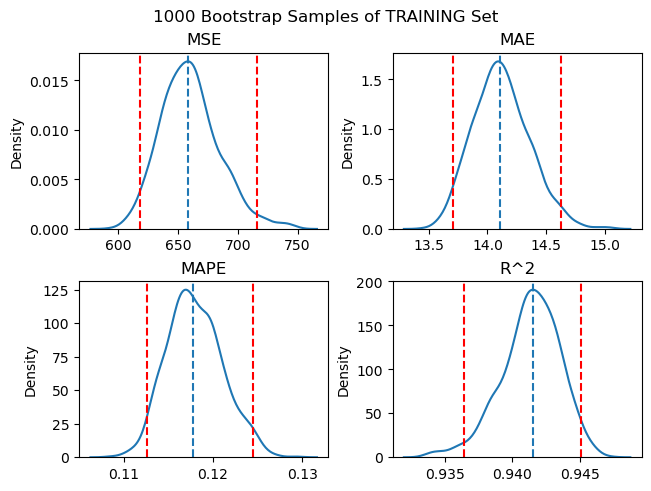

In [10]:
fig, axs = plt.subplots(2, 2, layout="constrained")
fig.suptitle('1000 Bootstrap Samples of TRAINING Set')
#MSE
sns.kdeplot(score_mse, ax=axs[0, 0])
axs[0, 0].axvline(median_mse, linestyle="--")
axs[0, 0].axvline(lower_mse, linestyle="--", color="red")
axs[0, 0].axvline(upper_mse, linestyle="--", color="red")
axs[0, 0].set_title('MSE')
#MAE
sns.kdeplot(score_mae, ax=axs[0, 1])
axs[0, 1].axvline(median_mae, linestyle="--")
axs[0, 1].axvline(lower_mae, linestyle="--", color="red")
axs[0, 1].axvline(upper_mae, linestyle="--", color="red")
axs[0, 1].set_title('MAE')
#MAPE
sns.kdeplot(score_mape, ax=axs[1, 0])
axs[1, 0].axvline(median_mape, linestyle="--")
axs[1, 0].axvline(lower_mape, linestyle="--", color="red")
axs[1, 0].axvline(upper_mape, linestyle="--", color="red")
axs[1, 0].set_title('MAPE')
#R^2
sns.kdeplot(score_r2, ax=axs[1, 1])
axs[1, 1].axvline(median_r2, linestyle="--")
axs[1, 1].axvline(lower_r2, linestyle="--", color="red")
axs[1, 1].axvline(upper_r2, linestyle="--", color="red")
axs[1, 1].set_title('R^2')

## Lasso regression
Selects features

In [ ]:
#HYPERPARAMETER TUNING (with a validation set?) to find best alpha
#see slide 37 ch.6

In [ ]:
#delete same-named variables:
del X_train, X_test, y_train, y_test, coef, coef_df, predict

In [ ]:
X=the_df.iloc[:, the_df.columns != the_df.columns[the_df.columns.get_loc('rate_avg')]] #select all columns except index 6 = rate_avg
print(X.shape)
y=the_df['rate_avg']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=156)

In [ ]:
from sklearn.linear_model import Lasso

#develop and fit the model
model_la = Lasso(alpha=0.1)
model_la.fit(X_train, y_train)
#predict using the model
predict = model_la.predict(X_test)

print('MAE: ', metrics.mean_absolute_error(y_test, predict))
print('MSE: ', metrics.mean_squared_error(y_test, predict))
print('MAPE: ', metrics.mean_absolute_percentage_error(y_test, predict))
print('R^2: ', r2_score(y_test, predict))
plt.scatter(y_test, predict)
plt.title('Using Lasso regression')

In [ ]:
#coeffs according to Lasso
coef = pd.DataFrame()
coef['feature_name'] = X_train.columns
coef['coefficients'] = pd.Series(model_la.coef_)
coef

Logistic regression:
1. Explore data: import data, find features, evaluate their shape, statistics, etc. --> done
2. Select features -->X/y
3. Split data into test and training
4. Develop model and fit into data, find coeff and intercept
5. Use model to predict
6. Evaluate the model using: MAE, MSE, RMSE, R^2, plot residuals!
7. Visualize accuracy with confusion matrix --> not for linear regression

to think about:
- feature selection: ridge, lasso, forward, backward...
- re-sampling: CV, bootstrap...

#### Feature selection

**Ridge** is your friend if you want to *keep* all features but stabilize the model. It doesn't remove multicollinearity, but it manages its damage to coefficients.

**Lasso** will *automatically pick one* from a correlated pair and zero out the other — but which one it picks can be somewhat arbitrary and unstable across runs/samples.

**Forward/Backward selection** is actually *worse* under multicollinearity because the decision to include/exclude a feature changes depending on what else is already in the model. --> not use it


%who: Lists all variables currently in the global scope.

%whos: Shows a detailed table of variables (type, size, and content).